In [21]:
%config InlineBackend.figure_format = 'svg'

In [22]:
import os

# ============================================
# Output Directory Setup
# ============================================

REPORT_DIR = "Reports"
os.makedirs(REPORT_DIR, exist_ok=True)

print(f"Reports directory ready at: {os.path.abspath(REPORT_DIR)}")

Reports directory ready at: /workspace/02_SystemArchitecture/BehavioralModels/Reports


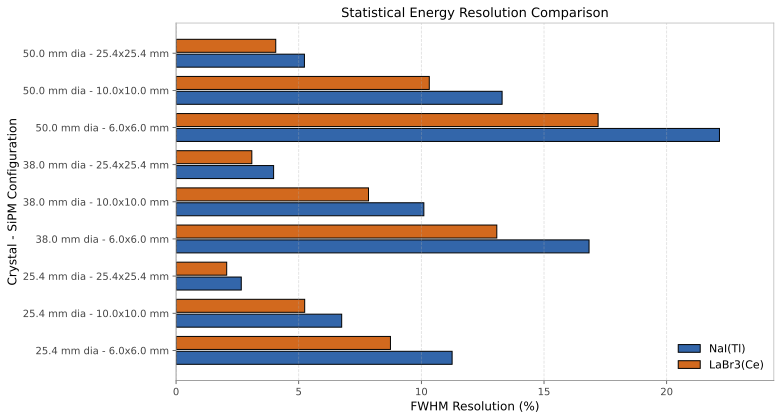

In [23]:
# ============================================
# Horizontal Comparison Plot
# ============================================

import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------- Styling ----------
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ---------- Prepare Labels ----------
crystal_labels = [f"{D} mm dia" for D in crystal_diameters]
sipm_labels = [f"{s}x{s} mm" for s in sipm_sizes]

config_labels = []
scint_names = list(resolution_matrix.keys())

# Support 2 scintillators (as in your original plot)
if len(scint_names) < 2:
    raise ValueError("Need at least two scintillators for comparison plot.")

vals_1 = []
vals_2 = []

for i, D in enumerate(crystal_diameters):
    for j, s in enumerate(sipm_sizes):
        label = f"{crystal_labels[i]} - {sipm_labels[j]}"
        config_labels.append(label)

        vals_1.append(resolution_matrix[scint_names[0]][i, j])
        vals_2.append(resolution_matrix[scint_names[1]][i, j])

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(11, 6))

y = np.arange(len(config_labels))
offset = 0.2

ax.barh(y - offset, vals_1, height=0.35,
        color="#3366AA", edgecolor="black",
        label=scint_names[0])

ax.barh(y + offset, vals_2, height=0.35,
        color="#D2691E", edgecolor="black",
        label=scint_names[1])

ax.set_xlabel("FWHM Resolution (%)")
ax.set_ylabel("Crystal - SiPM Configuration")
ax.set_title("Statistical Energy Resolution Comparison")

ax.set_yticks(y)
ax.set_yticklabels(config_labels)

# Axis styling
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")
ax.spines["right"].set_color("#BBBBBB")
ax.spines["top"].set_color("#BBBBBB")

ax.tick_params(axis='x', colors='#444444')
ax.tick_params(axis='y', colors='#444444')

ax.grid(True, axis="x", linestyle="--", alpha=0.4, color="#AAAAAA")

ax.set_xlim(0, max(max(vals_1), max(vals_2)) * 1.1)

ax.legend(frameon=False, loc="lower right")

plt.tight_layout()

plt.savefig(
    os.path.join(REPORT_DIR, "Resolution_Comparison_Barplot.svg"),
    format="svg",
    bbox_inches="tight"
)

plt.show()

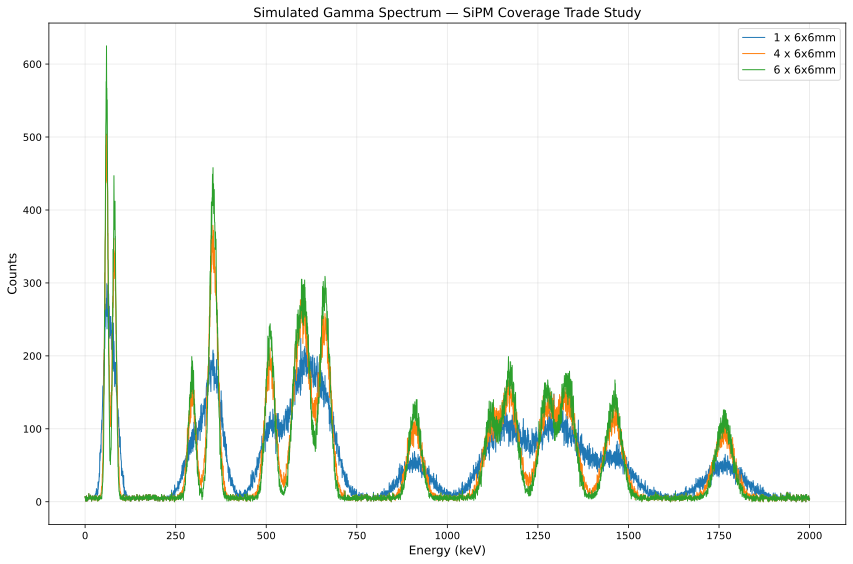

<Figure size 640x480 with 0 Axes>

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import yaml

from sipm_energy_resolution_model import (
    simulate_spectrum,
    fwhm_scaled_by_sipm_count
)

# ============================================
# Load Configuration
# ============================================
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

# ============================================
# Extract Parameters
# ============================================
energy_max = cfg["energy_axis"]["max_kev"]
bins = cfg["energy_axis"]["bins"]
energy_axis = np.linspace(0, energy_max, bins)

events_per_peak = cfg["simulation"]["events_per_peak"]
background_rate = cfg["simulation"]["background_rate"]
seed = cfg["simulation"].get("seed", None)

fwhm_single = cfg["detector"]["fwhm_single_662"]

# Parse isotopes into list of tuples
isotopes = [
    (iso["energy_kev"], iso["intensity"])
    for iso in cfg["isotopes"]
]

sipm_configs = cfg["sipm_configurations"]

# ============================================
# Plot Spectra
# ============================================
plt.figure(figsize=(12, 8))

for label, param in sipm_configs.items():
    n_sipm = param["n_sipm"]
    fwhm = fwhm_scaled_by_sipm_count(fwhm_single, n_sipm)

    spectrum = simulate_spectrum(
        isotopes=isotopes,
        fwhm_662=fwhm,
        energy_max=energy_max,
        bins=bins,
        events_per_peak=events_per_peak,
        background_rate=background_rate,
        seed=seed,
    )

    plt.plot(energy_axis, spectrum, label=label, linewidth=1)

plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("Simulated Gamma Spectrum — SiPM Coverage Trade Study")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.savefig(
    os.path.join(REPORT_DIR, "Gamma_Spectrum_Plot.svg"),
    format="svg",
    bbox_inches="tight"
)

TypeError: unsupported operand type(s) for /: 'str' and 'str'

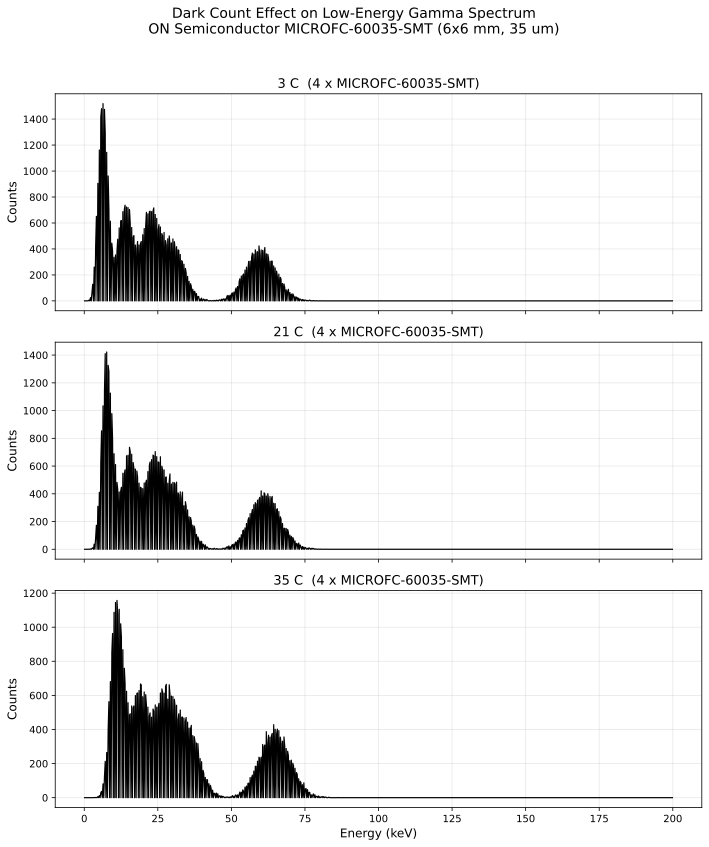

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from dark_count_noise_model import simulate_sipm_spectrum

# =============================================================================
# Random Generator
# =============================================================================

rng = np.random.default_rng(seed=55)

# =============================================================================
# System-Level Parameters
# =============================================================================

n_sipm          = 4
pe_per_kev      = 0.59 * n_sipm
integration_time = 1e-6   # seconds

e_max  = 200.0
n_bins = 800

isotopes = [
    (5.9,  1.0),   # Fe-55
    (13.5, 0.7),   # Am-241
    (22.0, 0.8),   # Cd-109
    (30.0, 0.6),   # Ba-133
    (59.5, 0.8),   # Am-241
]

events_per_peak = 15000
temperatures    = [3, 21, 35]

# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(len(temperatures), 1,
                         figsize=(10, 12),
                         sharex=True)

for ax, temp in zip(axes, temperatures):

    spectrum, bin_centers = simulate_sipm_spectrum(
        temperature_c    = temp,
        isotopes         = isotopes,
        events_per_peak  = events_per_peak,
        pe_per_kev       = pe_per_kev,
        n_sipm           = n_sipm,
        integration_time = integration_time,
        n_bins           = n_bins,
        e_max            = e_max,
        rng              = rng,
    )

    ax.plot(bin_centers, spectrum, color="black", linewidth=1.2)
    ax.set_title(f"{temp:.0f} C  (4 x MICROFC-60035-SMT)")
    ax.set_ylabel("Counts")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Energy (keV)")

fig.suptitle(
    "Dark Count Effect on Low-Energy Gamma Spectrum\n"
    "ON Semiconductor MICROFC-60035-SMT (6x6 mm, 35 um)",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    REPORT_DIR / "SpectrumDarkCountMICROFC60035.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()